## Verificação de Arquivos da pasta

In [3]:
from pathlib import Path
METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/best_tests")
print("Arquivos na pasta:")
for f in METRICS_BASE.glob("*"):
    print(f"  {f.name} (tamanho: {f.stat().st_size if f.is_file() else 'pasta'})")

Arquivos na pasta:
  dct_mid_combo_transformed (tamanho: pasta)
  dct_photo_dct_high_tau088_transformed (tamanho: pasta)
  dct_mid_combo.per_image.csv (tamanho: 18323)
  dtcwt_lssim10_id15_photo.csv (tamanho: 387)
  dtcwt_photo_dct_high_tau088.json (tamanho: 461)
  dtcwt_mid_combo.json (tamanho: 449)
  dtcwt_photo_dct_high_tau088.csv (tamanho: 391)
  dct_lssim10_id15_photo_transformed (tamanho: pasta)
  dtcwt_photo_dct_high_tau088.per_image.csv (tamanho: 18350)
  dct_lssim10_id15_photo.csv (tamanho: 386)
  dct_lssim10_id15_photo.json (tamanho: 456)
  dct_mid_combo.json (tamanho: 447)
  dtcwt_mid_combo.per_image.csv (tamanho: 18371)
  summary_best.csv (tamanho: 669)
  dtcwt_photo_dct_high_tau088_transformed (tamanho: pasta)
  dct_photo_dct_high_tau088.per_image.csv (tamanho: 18333)
  dtcwt_mid_combo_transformed (tamanho: pasta)
  dtcwt_lssim10_id15_photo_transformed (tamanho: pasta)
  dtcwt_lssim10_id15_photo.per_image.csv (tamanho: 18391)
  dtcwt_lssim10_id15_photo.json (tamanho: 457)


In [3]:
from pathlib import Path
METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/nopx")
print("Arquivos na pasta:")
for f in METRICS_BASE.glob("*"):
    print(f"  {f.name} (tamanho: {f.stat().st_size if f.is_file() else 'pasta'})")

Arquivos na pasta:
  mid_combo_amp20_flow45_nopx_transformed (tamanho: pasta)
  mid_combo_dtcwt_nopx.per_image.csv (tamanho: 18383)
  lssim10_id15_photo_dct_nopx.csv (tamanho: 385)
  lssim10_id15_photo_dtcwt_nopx.csv (tamanho: 388)
  lssim10_id15_photo_dct_nopx.per_image.csv (tamanho: 18375)
  lssim10_id15_photo_dtcwt_nopx.per_image.csv (tamanho: 18388)
  lssim10_id15_photo_dct_nopx.json (tamanho: 455)
  mid_combo_dtcwt_nopx.json (tamanho: 439)
  summary_all.csv (tamanho: 960)
  mid_combo_dct_nopx.json (tamanho: 447)
  mid_combo_dct_nopx.per_image.csv (tamanho: 18384)
  lssim10_id15_photo_dtcwt_nopx.json (tamanho: 458)
  mid_combo_amp20_flow45_nopx.per_image.csv (tamanho: 18405)
  mid_combo_dtcwt_nopx_transformed (tamanho: pasta)
  mid_combo_amp20_flow45_nopx.json (tamanho: 457)
  mid_combo_dct_nopx.csv (tamanho: 377)
  mid_combo_dtcwt_nopx.csv (tamanho: 369)
  mid_combo_dct_nopx_transformed (tamanho: pasta)
  lssim10_id15_photo_dtcwt_nopx_transformed (tamanho: pasta)
  mid_combo_amp20

# Verificação da cobertura do método

## DCT & DT-CWT (original loss function)

Encontrados 8 modelos com resultados por imagem:
  - dtcwt_mid_combo


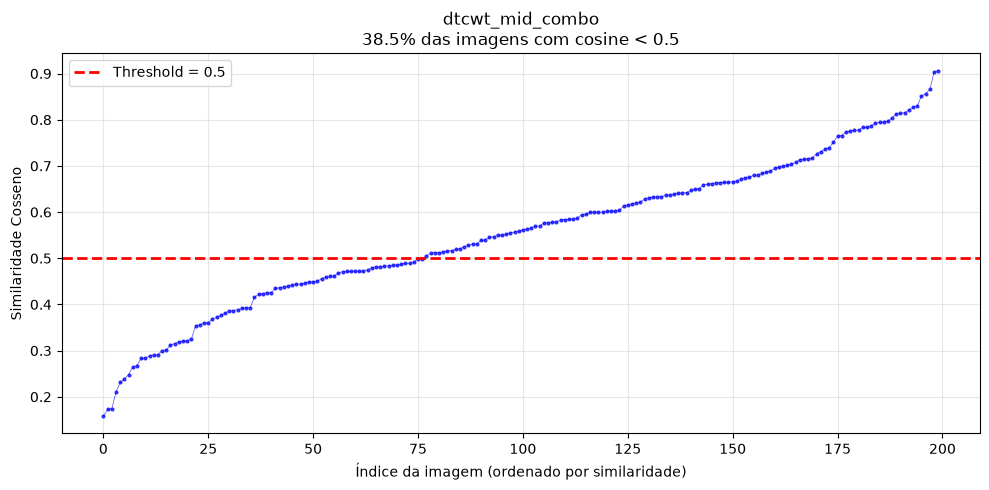

  - dtcwt_photo_dct_high_tau088


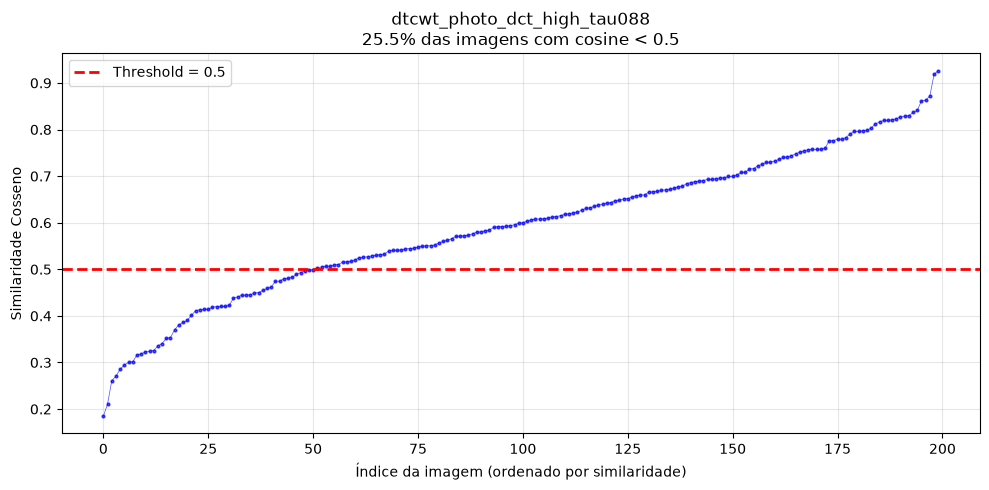

  - aggressive_mid_combo_amp20_flow45


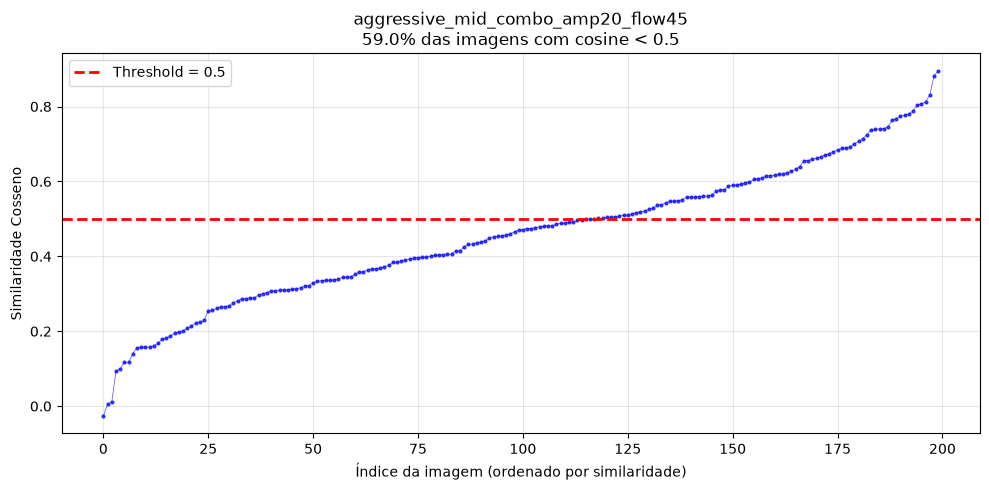

  - dct_photo_dct_high_tau088


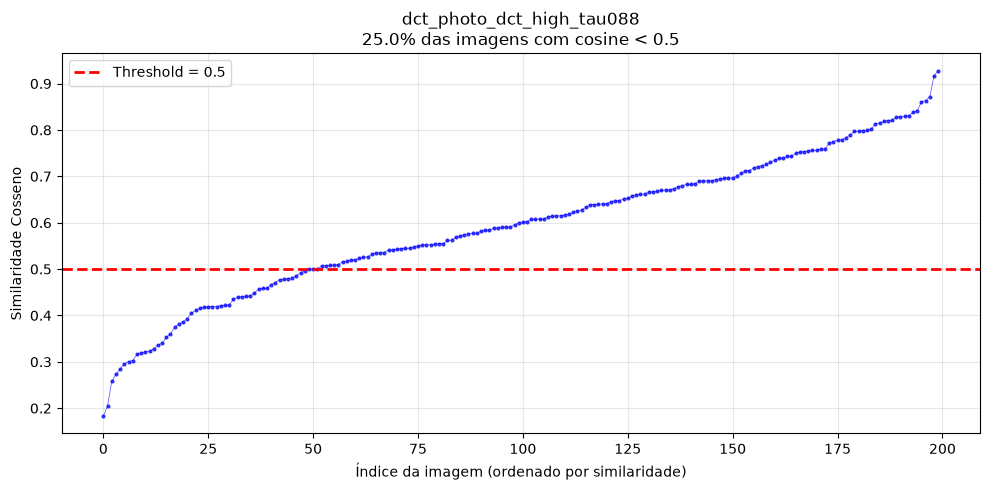

  - dtcwt_lssim10_id15_photo


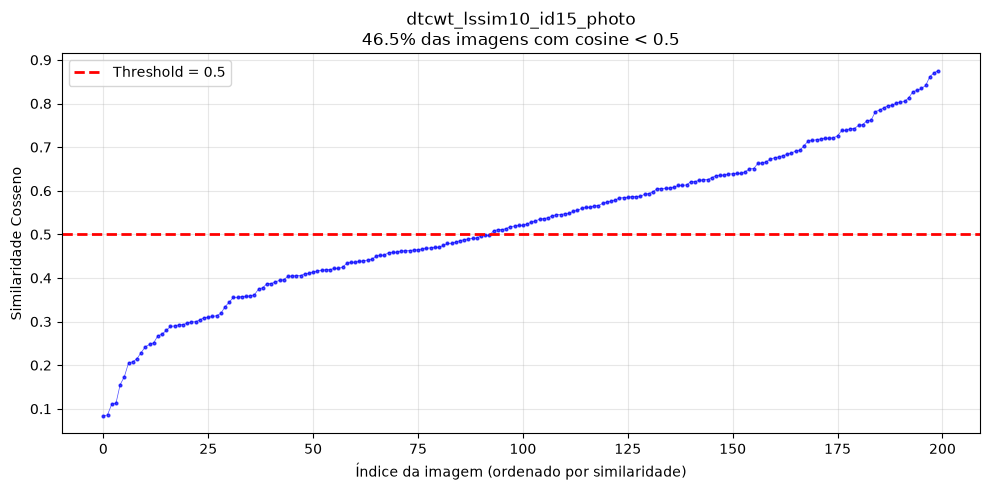

  - dct_mid_combo


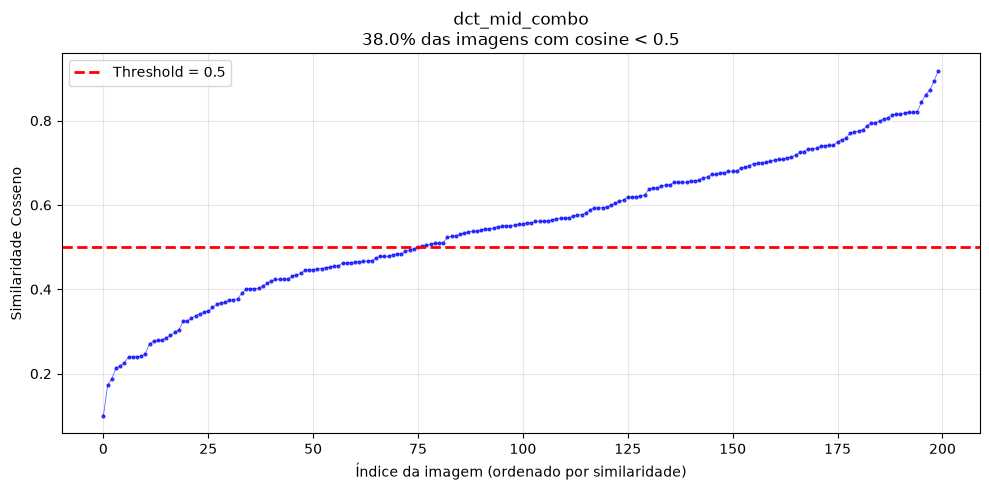

  - aggressive_extreme_amp35_id50_t03


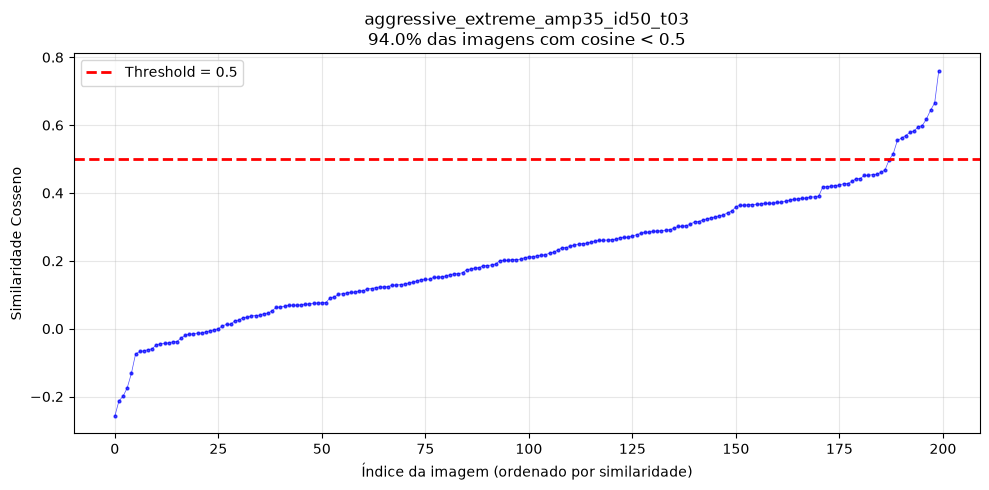

  - dct_lssim10_id15_photo


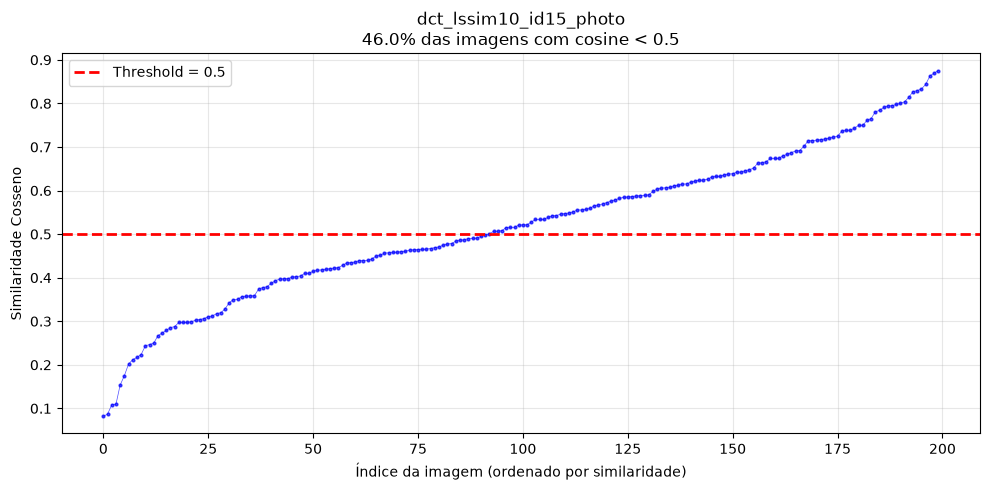

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/best_tests")
THRESHOLD = 0.5

model_dirs = [d for d in METRICS_BASE.iterdir() if d.is_dir() and (d / f"{d.name}.per_image.csv").exists()]

def plot_model(model_dir):
    model_name = model_dir.name
    per_image_csv = model_dir / f"{model_name}.per_image.csv"
    if not per_image_csv.exists():
        print(f"Arquivo não encontrado: {per_image_csv}")
        return
    
    df = pd.read_csv(per_image_csv)
    df = df.sort_values('cosine').reset_index(drop=True)
    n = len(df)
    below = (df['cosine'] < THRESHOLD).sum()
    percent = (below / n) * 100
    
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(df.index, df['cosine'], 'b-', alpha=0.7, linewidth=0.5, marker='o', markersize=2)
    ax.axhline(y=THRESHOLD, color='r', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
    ax.set_xlabel('Índice da imagem (ordenado por similaridade)')
    ax.set_ylabel('Similaridade Cosseno')
    ax.set_title(f'{model_name}\n{percent:.1f}% das imagens com cosine < {THRESHOLD}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"Encontrados {len(model_dirs)} modelos com resultados por imagem:")
for d in model_dirs:
    print(f"  - {d.name}")
    plot_model(d)

## Best Tests w/o px loss

Encontrados 5 arquivos de resultados por imagem:
  - Processando: mid_combo_dtcwt_nopx.per_image.csv


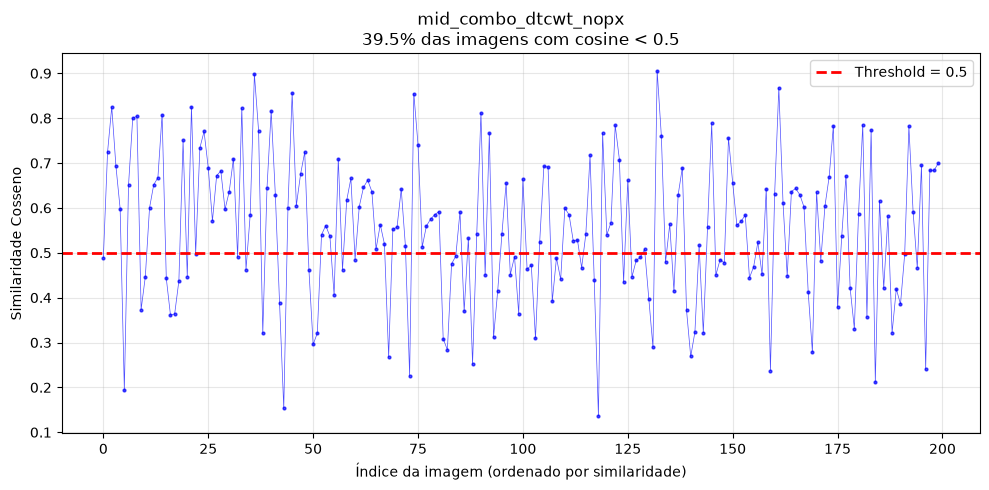

  - Processando: lssim10_id15_photo_dct_nopx.per_image.csv


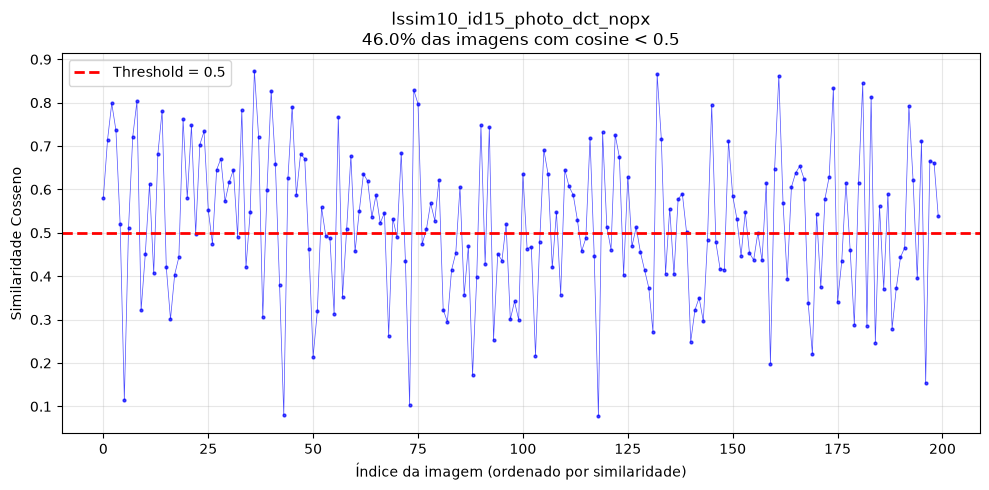

  - Processando: lssim10_id15_photo_dtcwt_nopx.per_image.csv


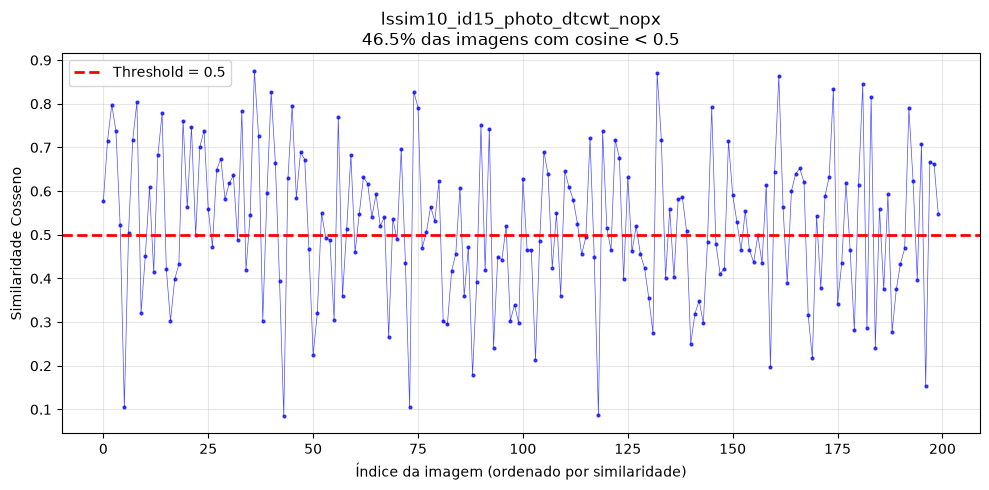

  - Processando: mid_combo_dct_nopx.per_image.csv


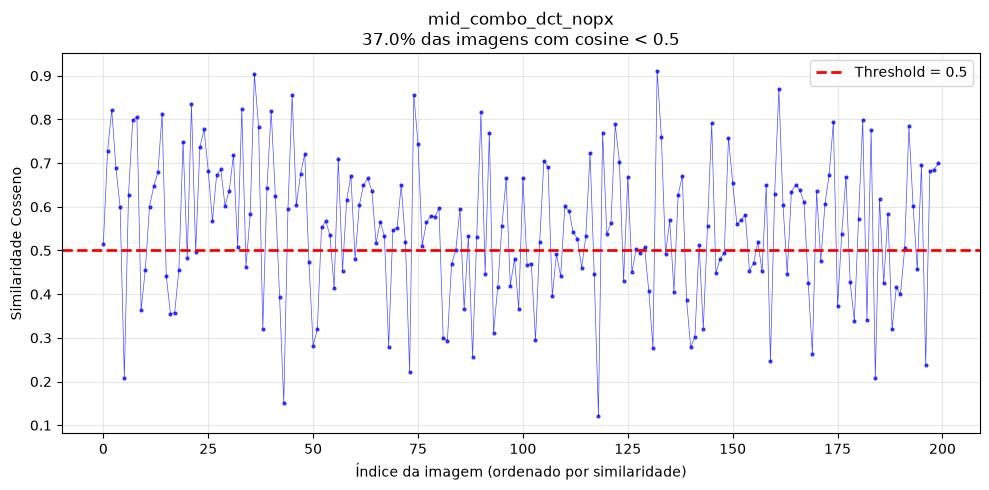

  - Processando: mid_combo_amp20_flow45_nopx.per_image.csv


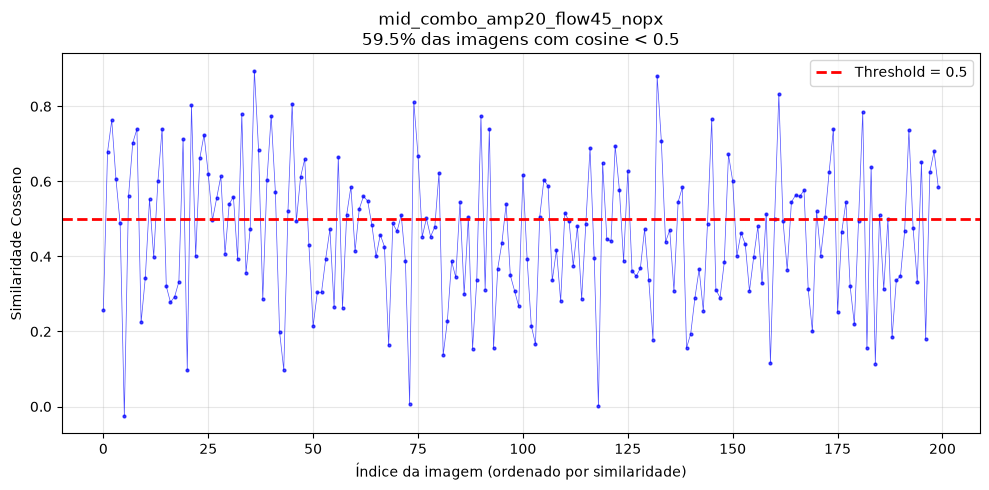

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Caminho para a sua pasta principal onde estão os arquivos
METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/nopx")
THRESHOLD = 0.5

# 1. Encontra todos os arquivos .per_image.csv diretamente na pasta
per_image_files = list(METRICS_BASE.glob("*.per_image.csv"))

def plot_model(csv_path):
    # Extrai o nome do modelo removendo o sufixo '.per_image.csv'
    model_name = csv_path.name.replace(".per_image.csv", "")
    
    df = pd.read_csv(csv_path)
    
    # Se quiser ordenar por similaridade como estava no seu comentário, descomente a linha abaixo:
    # df = df.sort_values('cosine').reset_index(drop=True)
    
    n = len(df)
    if n == 0:
        print(f"O arquivo {csv_path.name} está vazio.")
        return
        
    below = (df['cosine'] < THRESHOLD).sum()
    percent = (below / n) * 100
    
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(df.index, df['cosine'], 'b-', alpha=0.7, linewidth=0.5, marker='o', markersize=2)
    ax.axhline(y=THRESHOLD, color='r', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
    ax.set_xlabel('Índice da imagem (ordenado por similaridade)')
    ax.set_ylabel('Similaridade Cosseno')
    ax.set_title(f'{model_name}\n{percent:.1f}% das imagens com cosine < {THRESHOLD}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"Encontrados {len(per_image_files)} arquivos de resultados por imagem:")
for csv_file in per_image_files:
    print(f"  - Processando: {csv_file.name}")
    plot_model(csv_file)

Figura salva em: /mnt/study-data/dcarvalho/metrics/nopx/overlaid_similarity_curves.png


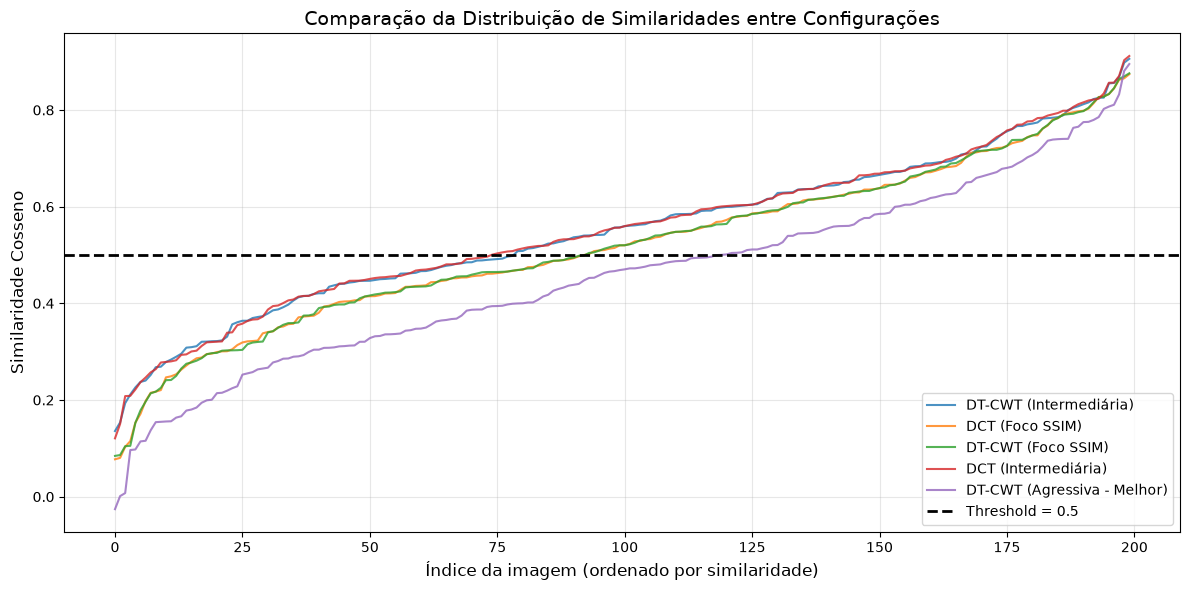

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Caminho para a sua pasta principal onde estão os arquivos .per_image.csv
METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/nopx")
THRESHOLD = 0.5
OUTPUT_PATH = Path("/mnt/study-data/dcarvalho/metrics/nopx/overlaid_similarity_curves.png")  # ajuste o path

# Encontra todos os arquivos .per_image.csv
per_image_files = list(METRICS_BASE.glob("*.per_image.csv"))

# Mapeamento para nomes bonitos na legenda
NICE_NAMES = {
    "lssim10_id15_photo_dct_nopx": "DCT (Foco SSIM)",
    "lssim10_id15_photo_dtcwt_nopx": "DT-CWT (Foco SSIM)",
    "mid_combo_dct_nopx": "DCT (Intermediária)",
    "mid_combo_dtcwt_nopx": "DT-CWT (Intermediária)",
    "mid_combo_amp20_flow45_nopx": "DT-CWT (Agressiva - Melhor)",
}

plt.figure(figsize=(12, 6))

for csv_file in per_image_files:
    df = pd.read_csv(csv_file)
    # Ordena por similaridade para gerar a curva crescente
    df = df.sort_values('cosine', ascending=True).reset_index(drop=True)
    
    model_name = csv_file.stem.replace(".per_image", "")  # remove sufixo
    label = NICE_NAMES.get(model_name, model_name)
    
    plt.plot(df.index, df['cosine'], linewidth=1.5, alpha=0.8, label=label)

# Linha do threshold
plt.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')

plt.xlabel('Índice da imagem (ordenado por similaridade)', fontsize=12)
plt.ylabel('Similaridade Cosseno', fontsize=12)
plt.title('Comparação da Distribuição de Similaridades entre Configurações', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salva a figura
plt.savefig(OUTPUT_PATH, dpi=300)
print(f"Figura salva em: {OUTPUT_PATH}")

# Exibe
plt.show()

Figura salva em: /mnt/study-data/dcarvalho/metrics/prelim_ablation/overlaid_similarity_curves.png


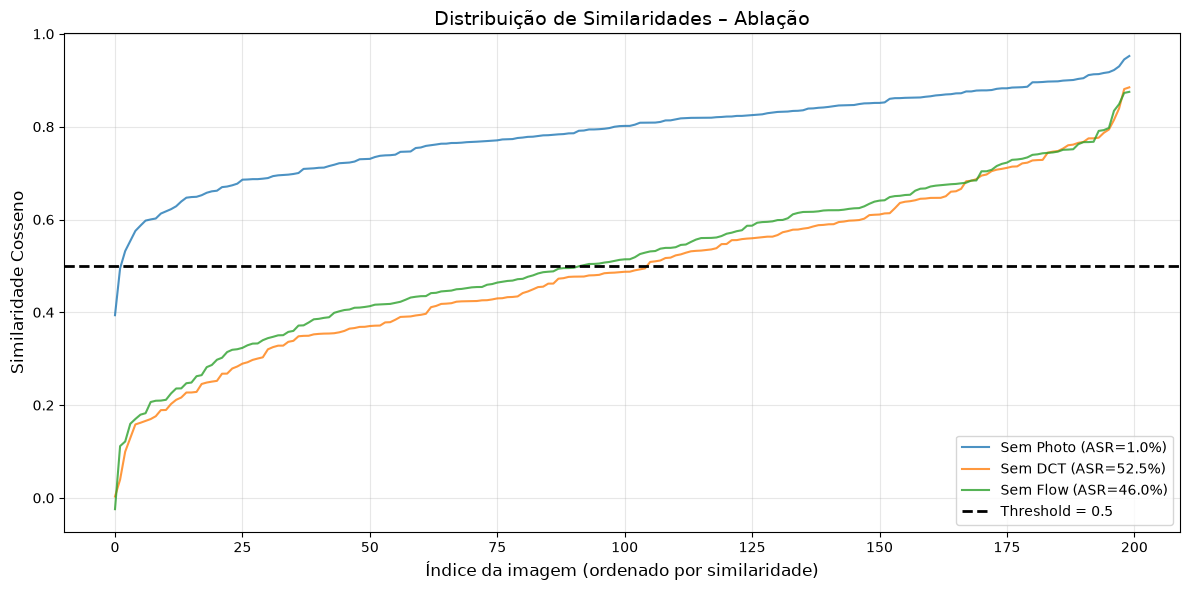


ATTACK SUCCESS RATE (ASR) - Threshold = 0.5
Modelo                       ASR (%)
--------------------------------------------------
Sem DCT                         52.5
Sem Flow                        46.0
Sem Photo                        1.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIGURAÇÕES
# ============================================================

METRICS_BASE = Path("/mnt/study-data/dcarvalho/metrics/prelim_ablation")
THRESHOLD = 0.5
OUTPUT_PATH = METRICS_BASE / "overlaid_similarity_curves.png"

# Mapeamento para nomes bonitos
NICE_NAMES = {
    "mid_combo_no_dct": "Sem DCT",
    "mid_combo_no_flow": "Sem Flow",
    "mid_combo_no_photo": "Sem Photo",
    # Se quiser incluir o baseline, adicione aqui
    # "mid_combo_amp20_flow45_nopx": "Completo (Baseline)",
}

# ============================================================
# CALCULAR ASR E PREPARAR DADOS
# ============================================================

per_image_files = list(METRICS_BASE.glob("*.per_image.csv"))
asr_results = []

plt.figure(figsize=(12, 6))

for csv_file in per_image_files:
    df = pd.read_csv(csv_file)
    # Ordena por similaridade
    df = df.sort_values('cosine', ascending=True).reset_index(drop=True)
    
    model_name = csv_file.stem.replace(".per_image", "")
    label = NICE_NAMES.get(model_name, model_name)
    
    # Calcula ASR
    n_total = len(df)
    n_below = (df['cosine'] < THRESHOLD).sum()
    asr = (n_below / n_total) * 100
    asr_results.append((label, asr))
    
    # Plot com ASR na legenda
    plt.plot(df.index, df['cosine'], linewidth=1.5, alpha=0.8, 
             label=f"{label} (ASR={asr:.1f}%)")

# Linha do threshold
plt.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold = {THRESHOLD}')

plt.xlabel('Índice da imagem (ordenado por similaridade)', fontsize=12)
plt.ylabel('Similaridade Cosseno', fontsize=12)
plt.title('Distribuição de Similaridades – Ablação', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUT_PATH, dpi=300)
print(f"Figura salva em: {OUTPUT_PATH}")
plt.show()

# ============================================================
# EXIBIR TABELA DE ASR
# ============================================================

print("\n" + "="*50)
print("ATTACK SUCCESS RATE (ASR) - Threshold = {}".format(THRESHOLD))
print("="*50)
print(f"{'Modelo':<25} {'ASR (%)':>10}")
print("-"*50)
for label, asr in sorted(asr_results, key=lambda x: x[1], reverse=True):
    print(f"{label:<25} {asr:>10.1f}")
print("="*50)

In [ ]:
#!/usr/bin/env python3
import os
import shutil
import zipfile
from pathlib import Path

# ===== CONFIGURAÇÕES =====
BASE_METRICS = Path("/mnt/study-data/dcarvalho/metrics/prelim_ablation")
BASE_LFW = Path("/mnt/study-data/dcarvalho/datasets/lfw/faces_test")
TARGET_DIR = Path("/mnt/study-data/dcarvalho/quali_files")
ORIG_SUBDIR = TARGET_DIR / "orig"

# Lista de pastas fonte e respectivos prefixos para renomeação
FOLDERS = {
    "mid_combo_no_flow_transformed": "noflow",
    "mid_combo_no_photo_transformed": "nophoto",
    "mid_combo_no_dct_transformed": "nodct",
}

# Arquivos a serem copiados (nomes base, sem _transformed)
IMAGE_NAMES = [
    "img_000041",
    "img_000039",
    "img_000031",
    "img_000017",
    "img_000008",
]

# ===== CRIAÇÃO DOS DIRETÓRIOS =====
TARGET_DIR.mkdir(parents=True, exist_ok=True)
ORIG_SUBDIR.mkdir(parents=True, exist_ok=True)

# ===== FUNÇÃO PARA COPIAR E RENOMEAR =====
def copy_and_rename_images():
    for folder, prefix in FOLDERS.items():
        src_dir = BASE_METRICS / folder
        if not src_dir.exists():
            print(f"⚠️  Pasta não encontrada: {src_dir}")
            continue

        for img_base in IMAGE_NAMES:
            src_file = src_dir / f"{img_base}_transformed.jpg"
            if not src_file.exists():
                print(f"⚠️  Arquivo não encontrado: {src_file}")
                continue

            # Novo nome: prefixo + img_base + .jpg
            dest_name = f"{prefix}_{img_base}.jpg"
            dest_file = TARGET_DIR / dest_name
            shutil.copy2(src_file, dest_file)
            print(f"✅ Copiado: {src_file} -> {dest_file}")

# ===== COPIAR IMAGENS ORIGINAIS =====
def copy_original_images():
    for img_base in IMAGE_NAMES:
        src_file = BASE_LFW / f"{img_base}.jpg"
        if not src_file.exists():
            print(f"⚠️  Original não encontrado: {src_file}")
            continue
        dest_file = ORIG_SUBDIR / f"{img_base}.jpg"
        shutil.copy2(src_file, dest_file)
        print(f"✅ Copiado original: {src_file} -> {dest_file}")

# ===== COMPACTAR PARA ZIP =====
def compress_folder():
    zip_name = TARGET_DIR.with_suffix(".zip")
    # Remove zip antigo se existir
    if zip_name.exists():
        zip_name.unlink()

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(TARGET_DIR):
            # Evita incluir o próprio zip dentro do zip (caso ele já exista no diretório)
            # Como criamos o zip fora do diretório, não há risco.
            for file in files:
                file_path = Path(root) / file
                # Caminho relativo dentro do zip (a partir de TARGET_DIR)
                arcname = file_path.relative_to(TARGET_DIR.parent)
                zipf.write(file_path, arcname)
                print(f"📦 Adicionado ao ZIP: {arcname}")

    print(f"\n📁 Arquivo ZIP criado: {zip_name}")

# ===== EXECUÇÃO PRINCIPAL =====
if __name__ == "__main__":
    print("🚀 Iniciando processo...")
    copy_and_rename_images()
    copy_original_images()
    compress_folder()
    print("✅ Processo concluído!")